
--- What would you like to plot? ---
1) Humidity
2) Temperature
3) Both


Enter choice (1, 2, or 3):  3



--- Select Time Interval ---
1) Last 7 days
2) Last 30 days
3) Specific interval
4) All


Enter choice (1, 2, 3, or 4):  1



Graph saved successfully as 'sensor_graph.png'


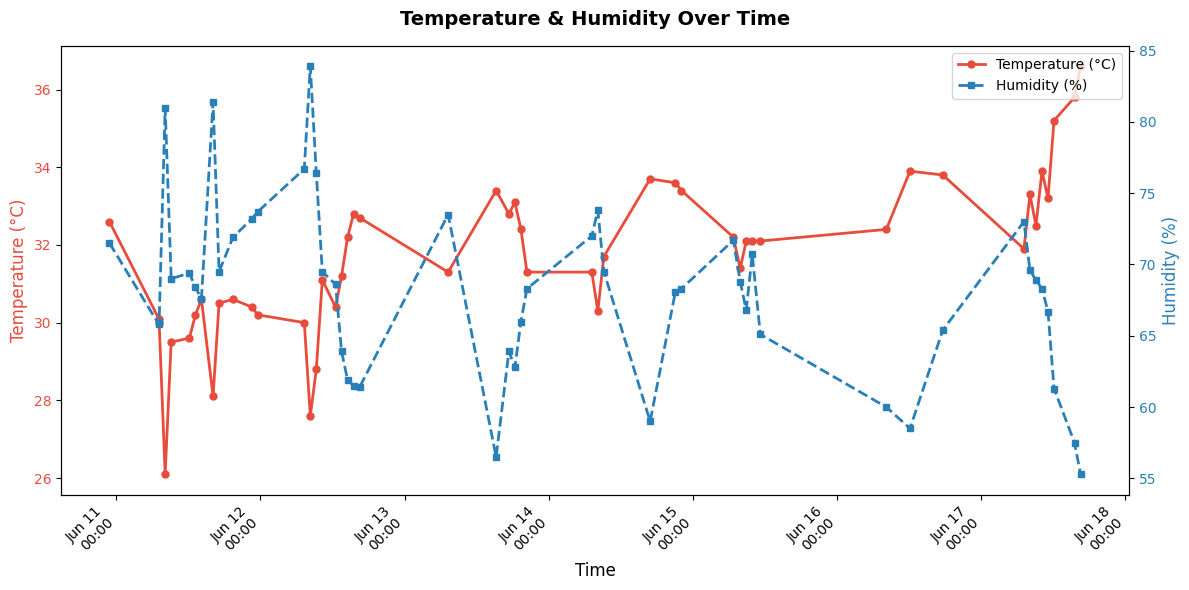

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Load and clean data
df = pd.read_csv("sensor_data.csv", parse_dates=["Timestamp"])
df.sort_values("Timestamp", inplace=True)

# Create a clean Date column (without time) for the specific interval menu
df['Date'] = df['Timestamp'].dt.date

# 2. Get Data Type Choice
print("\n--- What would you like to plot? ---")
print("1) Humidity")
print("2) Temperature")
print("3) Both")
data_choice = input("Enter choice (1, 2, or 3): ").strip()

# 3. Get Time Interval Choice
print("\n--- Select Time Interval ---")
print("1) Last 7 days")
print("2) Last 30 days")
print("3) Specific interval")
print("4) All")
interval_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

# Apply Time Interval Filtering
latest_date = df['Timestamp'].max()

if interval_choice == "1":
    start_filter = latest_date - pd.Timedelta(days=7)
    df = df[df['Timestamp'] >= start_filter]
    
elif interval_choice == "2":
    start_filter = latest_date - pd.Timedelta(days=30)
    df = df[df['Timestamp'] >= start_filter]
    
elif interval_choice == "3":
    # Get unique sorted dates from the dataset
    unique_dates = sorted(df['Date'].unique())
    
    print("\n--- Available Dates ---")
    for idx, date in enumerate(unique_dates, 1):
        print(f"{idx}) {date}")
        
    try:
        start_idx = int(input(f"\nEnter start date number (1-{len(unique_dates)}): ")) - 1
        end_idx = int(input(f"Enter end date number (1-{len(unique_dates)}): ")) - 1
        
        selected_start = unique_dates[start_idx]
        selected_end = unique_dates[end_idx]
        
        # Filter dataframe between the selected dates (inclusive)
        df = df[(df['Date'] >= selected_start) & (df['Date'] <= selected_end)]
    except (ValueError, IndexError):
        print("Invalid selection. Plotting 'All' data instead.")

elif interval_choice == "4":
    pass # Keep the whole dataframe
else:
    print("Invalid choice. Plotting 'All' data by default.")

# Check if we have data left after filtering
if df.empty:
    print("No data available for the selected interval. Exiting.")
    exit()

# 4. Plotting the Graph
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel("Time", fontsize=12)

# --- Plotting logic based on user choice ---
if data_choice == "1":
    # Humidity only
    color_hum = "#2980b9"
    ax1.set_ylabel("Humidity (%)", color=color_hum, fontsize=12)
    ax1.plot(df["Timestamp"], df["Humidity_Percent"],
             color=color_hum, marker="s", linewidth=2, linestyle="--",
             markersize=5, label="Humidity (%)")
    ax1.tick_params(axis="y", labelcolor=color_hum)
    ax1.legend(loc="upper right")
    plt.title("Humidity Over Time", fontsize=14, fontweight="bold", pad=15)

elif data_choice == "2":
    # Temperature only
    color_temp = "#e74c3c"
    ax1.set_ylabel("Temperature (°C)", color=color_temp, fontsize=12)
    ax1.plot(df["Timestamp"], df["Temperature_C"],
             color=color_temp, marker="o", linewidth=2,
             markersize=5, label="Temperature (°C)")
    ax1.tick_params(axis="y", labelcolor=color_temp)
    ax1.legend(loc="upper right")
    plt.title("Temperature Over Time", fontsize=14, fontweight="bold", pad=15)

else:
    # Both (Dual Y-Axis)
    color_temp = "#e74c3c"
    ax1.set_ylabel("Temperature (°C)", color=color_temp, fontsize=12)
    ax1.plot(df["Timestamp"], df["Temperature_C"],
             color=color_temp, marker="o", linewidth=2,
             markersize=5, label="Temperature (°C)")
    ax1.tick_params(axis="y", labelcolor=color_temp)

    color_hum = "#2980b9"
    ax2 = ax1.twinx()
    ax2.set_ylabel("Humidity (%)", color=color_hum, fontsize=12)
    ax2.plot(df["Timestamp"], df["Humidity_Percent"],
             color=color_hum, marker="s", linewidth=2, linestyle="--",
             markersize=5, label="Humidity (%)")
    ax2.tick_params(axis="y", labelcolor=color_hum)
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)
    plt.title("Temperature & Humidity Over Time", fontsize=14, fontweight="bold", pad=15)

# --- X-axis formatting ---
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)

fig.tight_layout()

# Save and Show
plt.savefig("sensor_graph.png", dpi=150)
print("\nGraph saved successfully as 'sensor_graph.png'")
plt.show()